<a href="https://colab.research.google.com/github/Erica4397/for_coding_camp1/blob/main/ForCodingCampNotebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Questions(listed from most to least interested)

How does the max_wind_knots, min_pressure_mb and more differ in a long lasting hurricane vs a shorter one(7 days)?

Are there more hurricanes/storms(be more specific - what type/category?) happening more frequently than before? Why?

How does the max_wind_knots, min_pressure_mb and more change as a hurricane progresses?

Import everything

In [ ]:
!pip install pandas
import pandas as pd
!pip install matplotlib
import matplotlib.pyplot as plt
import numpy as np
from sklearn import datasets, model_selection
import scipy.stats as stats
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn import metrics

Load in the dataset and take a look at it

In [ ]:
df = pd.read_csv("hurdat2_atlantic_1851_2025_filtered.csv")
#df.head()
#df['status'].unique()
#df['record_identifier'].unique()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55605 entries, 0 to 55604
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   storm_id           55605 non-null  object 
 1   name               55605 non-null  object 
 2   date               55605 non-null  object 
 3   time               55605 non-null  int64  
 4   record_identifier  1256 non-null   object 
 5   status             55605 non-null  object 
 6   latitude           55605 non-null  float64
 7   longitude          55605 non-null  float64
 8   max_wind_knots     55605 non-null  int64  
 9   min_pressure_mb    24659 non-null  float64
 10  year               55605 non-null  int64  
 11  month              55605 non-null  int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 5.1+ MB


Drop duplicates

In [ ]:
df_nodup = df.drop_duplicates()
df_nodup.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55605 entries, 0 to 55604
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   storm_id           55605 non-null  object 
 1   name               55605 non-null  object 
 2   date               55605 non-null  object 
 3   time               55605 non-null  int64  
 4   record_identifier  1256 non-null   object 
 5   status             55605 non-null  object 
 6   latitude           55605 non-null  float64
 7   longitude          55605 non-null  float64
 8   max_wind_knots     55605 non-null  int64  
 9   min_pressure_mb    24659 non-null  float64
 10  year               55605 non-null  int64  
 11  month              55605 non-null  int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 5.1+ MB


Deal with null values

In [ ]:
#Use the Atkinson-Holliday relationship to find the missing pressure(mb) using the max_wind_knots
missing = 1010 - (df_nodup['max_wind_knots'] / 6.7) ** (1 / 0.644)
df_nodup['min_pressure_mb'] = df_nodup['min_pressure_mb'].fillna(missing)

df_nodup[df_nodup.isna().any(axis=1)]

,storm_id,name,date,time,record_identifier,status,latitude,longitude,max_wind_knots,min_pressure_mb,year,month
0,AL011851,UNNAMED,1851-06-25,0,NaN,HU,28.0,-94.8,80,962.969042,1851,6
1,AL011851,UNNAMED,1851-06-25,600,NaN,HU,28.0,-95.4,80,962.969042,1851,6
2,AL011851,UNNAMED,1851-06-25,1200,NaN,HU,28.0,-96.0,80,962.969042,1851,6
3,AL011851,UNNAMED,1851-06-25,1800,NaN,HU,28.1,-96.5,80,962.969042,1851,6
5,AL011851,UNNAMED,1851-06-26,0,NaN,HU,28.2,-97.0,70,971.776168,1851,6
...,...,...,...,...,...,...,...,...,...,...,...,...
55600,AL132025,MELISSA,2025-10-31,600,NaN,HU,34.5,-65.5,75,972.000000,2025,10
55601,AL132025,MELISSA,2025-10-31,1200,NaN,EX,37.7,-62.1,75,972.000000,2025,10
55602,AL132025,MELISSA,2025-10-31,1800,NaN,EX,40.6,-58.9,70,972.000000,2025,10
55603,AL132025,MELISSA,2025-11-01,0,NaN,EX,43.7,-56.0,70,971.000000,2025,11


Scatter plot of the location of hurricanes

Text(0, 0.5, 'Longitude')

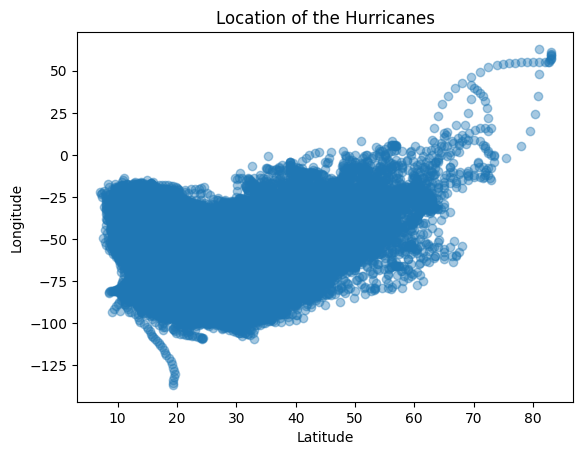

In [ ]:
plt.scatter(df_nodup['latitude'], df_nodup['longitude'], alpha = 0.4)
plt.title('Location of the Hurricanes')
plt.xlabel('Latitude')
plt.ylabel('Longitude')

___

Text(0, 0.5, 'Storm id')

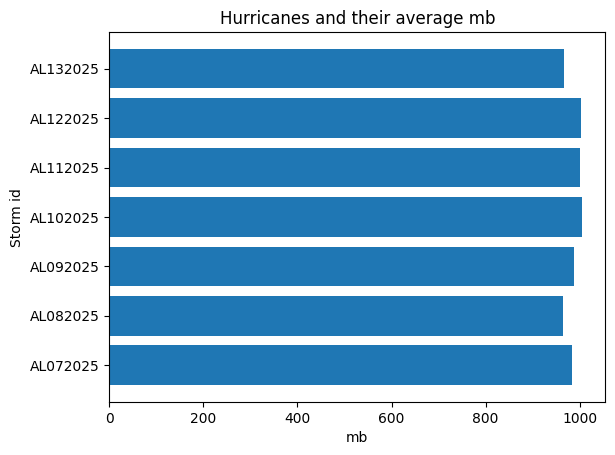

In [ ]:
df_last_200r = df.tail(200)
means = df_last_200r.groupby('storm_id')['min_pressure_mb'].mean()
plt.barh(means.index, means.values)

plt.title('Hurricanes and their average mb')
plt.xlabel('mb')
plt.ylabel('Storm id')

Hurricane's pressure over time(longer)

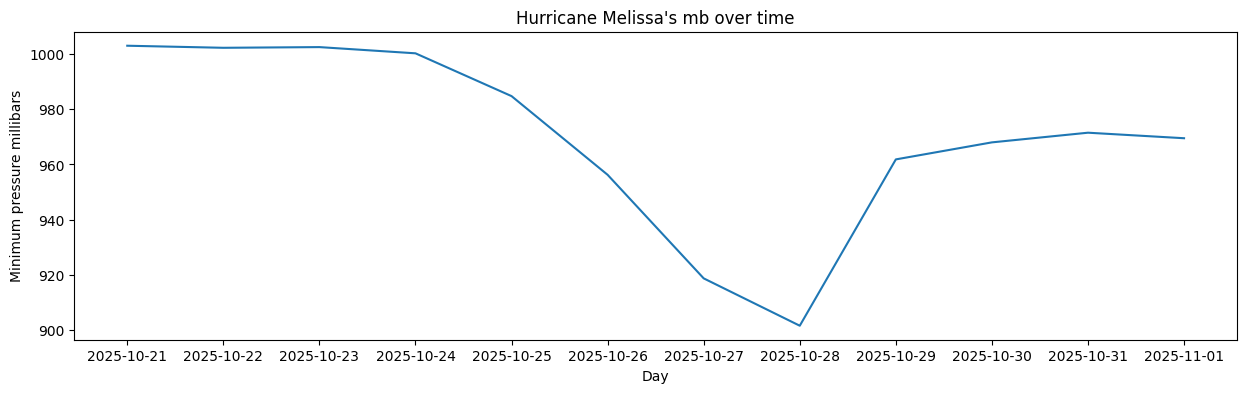

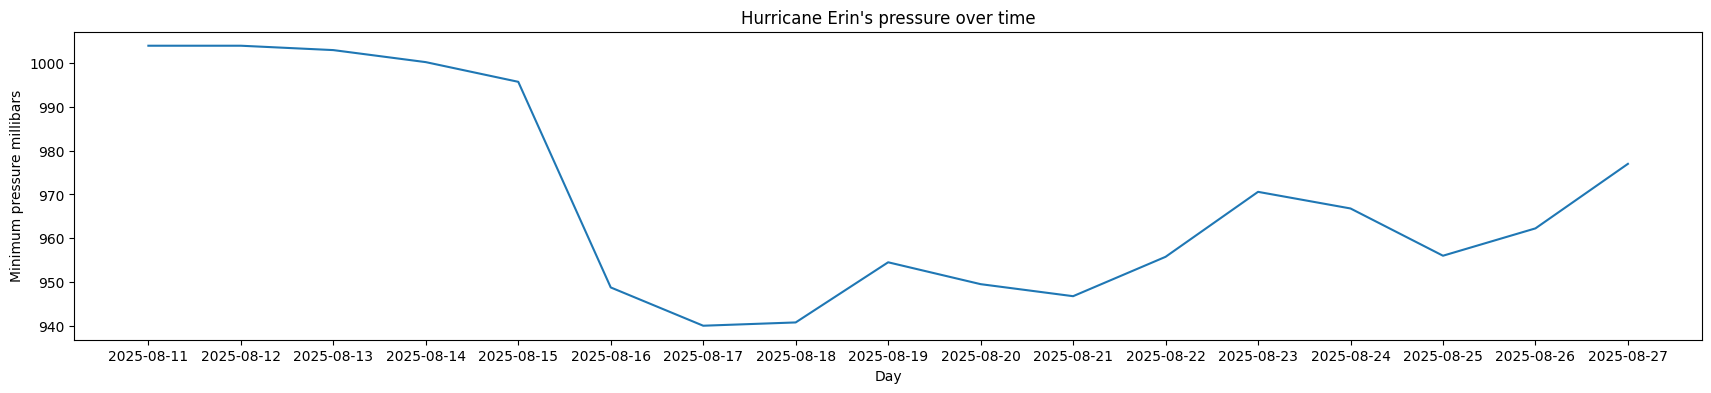

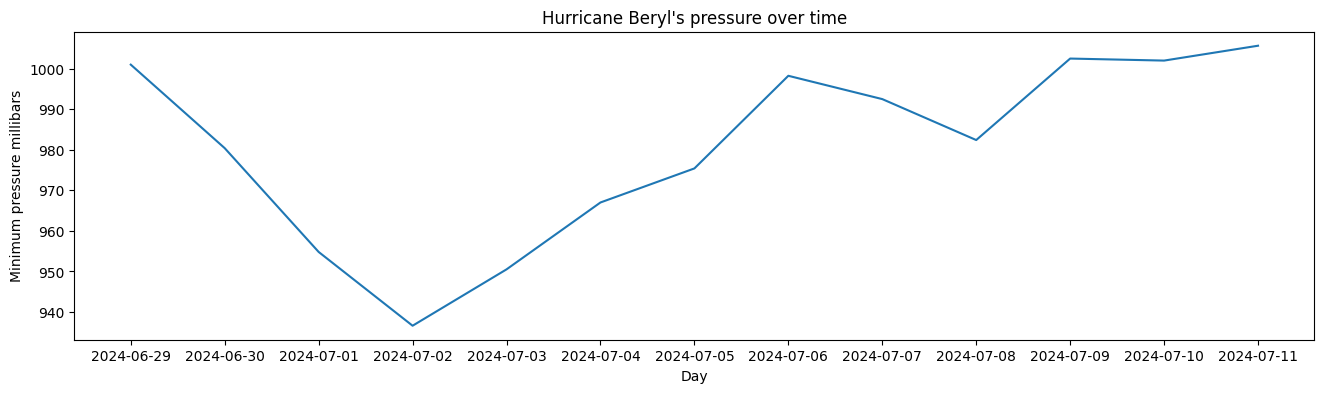

In [ ]:
#lasted around 10 days
#lowest point was 892(row 55586). Longitude was -78.1, latitude was 17.5.
#Note: lower mb means worse weather. Usually, the mb of the standard atmosphere is 1013.25
df_melissa = df_nodup.tail(49)

#x axis
df_m_mb = df_melissa.groupby('date')['min_pressure_mb'].mean()
df_m_mb = df_m_mb.reset_index()

plt.figure(figsize=(15, 4))
plt.plot(df_m_mb['date'], df_m_mb['min_pressure_mb'])
plt.title("Hurricane Melissa's mb over time")
plt.xlabel('Day')
plt.ylabel('Minimum pressure millibars')
plt.show()

################################################################################
df_erin = df_nodup[55314:55382]
df_e_date = df_erin.groupby('date')['min_pressure_mb'].mean()
df_e_date = df_e_date.reset_index()

plt.figure(figsize=(21, 4))
plt.plot(df_e_date['date'], df_e_date['min_pressure_mb'])

plt.title("Hurricane Erin's pressure over time")
plt.xlabel('Day')
plt.ylabel('Minimum pressure millibars')

#lasted about 17 days
plt.show
################################################################################

df_beryl = df_nodup[54762:54818]
df_b_date = df_beryl.groupby('date')['min_pressure_mb'].mean()
df_b_date = df_b_date.reset_index()

plt.figure(figsize=(16, 4))
plt.plot(df_b_date['date'], df_b_date['min_pressure_mb'])

plt.title("Hurricane Beryl's pressure over time")
plt.xlabel('Day')
plt.ylabel('Minimum pressure millibars')
# lasted about 14 days
plt.show()

Wind knots of longer lasting hurricanes/storms

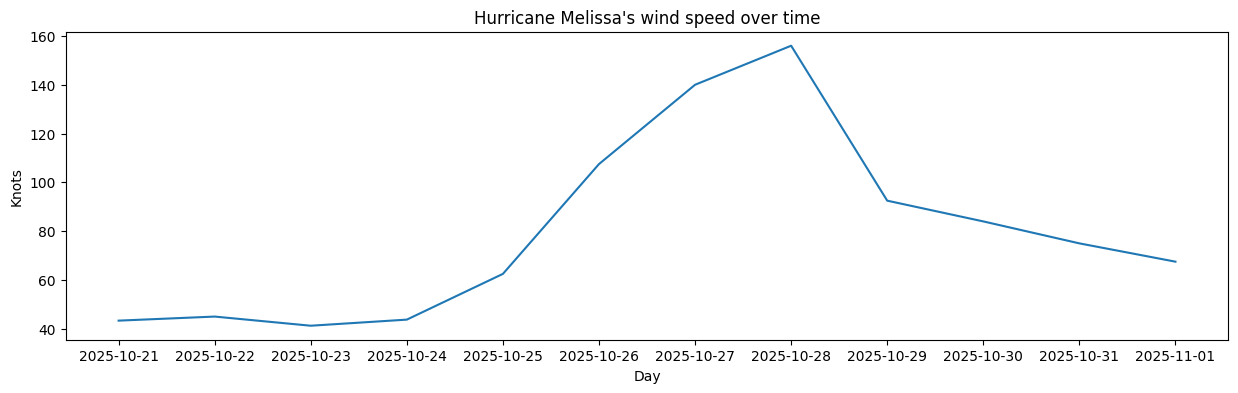

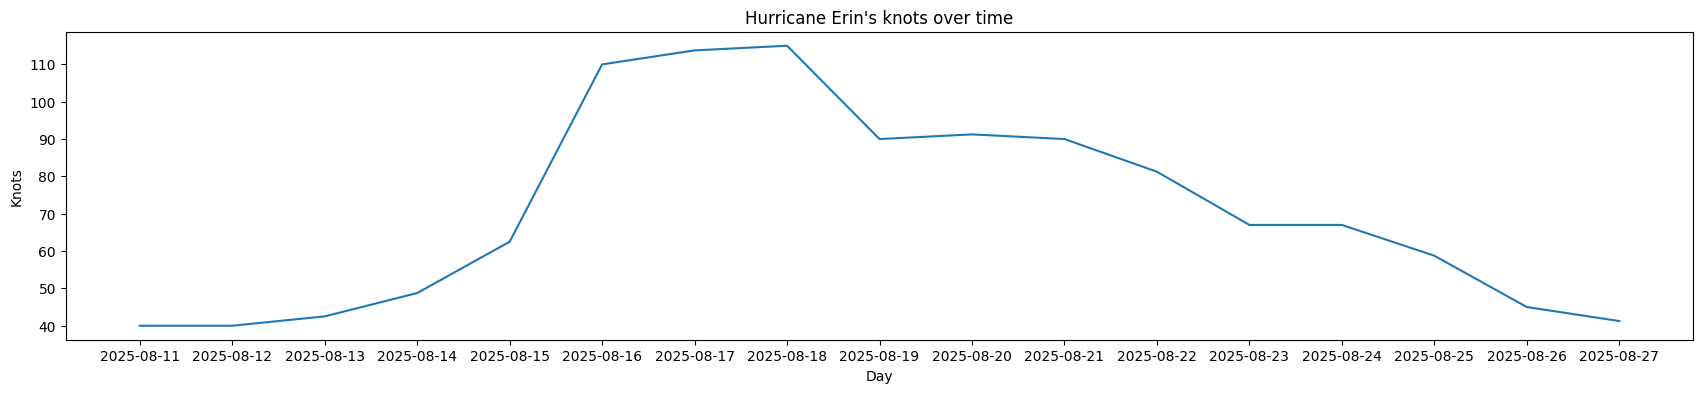

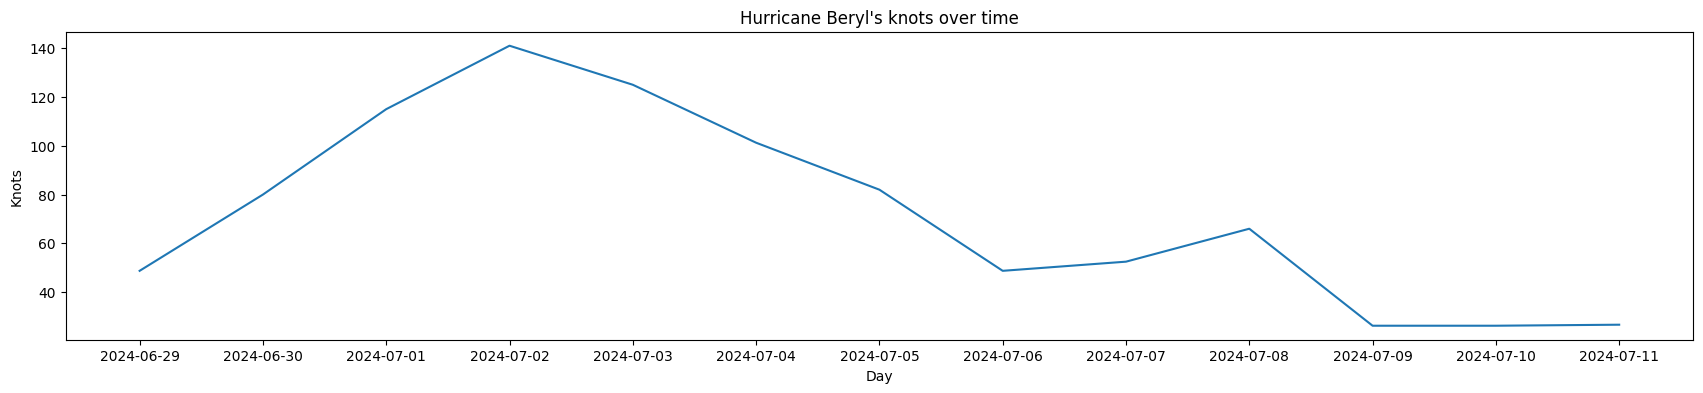

In [ ]:
#1kn is about 1.15 mph or 1.85 km/h
#The point where the knot is highest is when the mb is lowest.
#TS-->HU-->EX
df_m_knot = df_melissa.groupby('date')['max_wind_knots'].mean()
df_m_knot = df_m_knot.reset_index()

plt.figure(figsize=(15, 4))
plt.plot(df_m_knot['date'], df_m_knot['max_wind_knots'])

plt.title("Hurricane Melissa's wind speed over time")
plt.xlabel('Day')
plt.ylabel('Knots')
plt.show()
################################################################################
df_e_knot = df_erin.groupby('date')['max_wind_knots'].mean()
df_e_knot = df_e_knot.reset_index()

plt.figure(figsize=(21, 4))
plt.plot(df_e_knot['date'], df_e_knot['max_wind_knots'])

plt.title("Hurricane Erin's knots over time")
plt.xlabel('Day')
plt.ylabel('Knots')
plt.show()
################################################################################
df_b_knot = df_beryl.groupby('date')['max_wind_knots'].mean()
df_b_knot = df_b_knot.reset_index()

plt.figure(figsize=(21, 4))
plt.plot(df_b_knot['date'], df_b_knot['max_wind_knots'])

plt.title("Hurricane Beryl's knots over time")
plt.xlabel('Day')
plt.ylabel('Knots')
plt.show()

_______

Pressure over time(shorter)

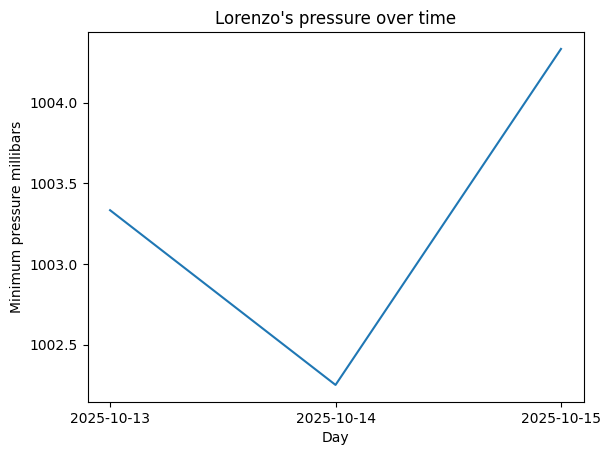

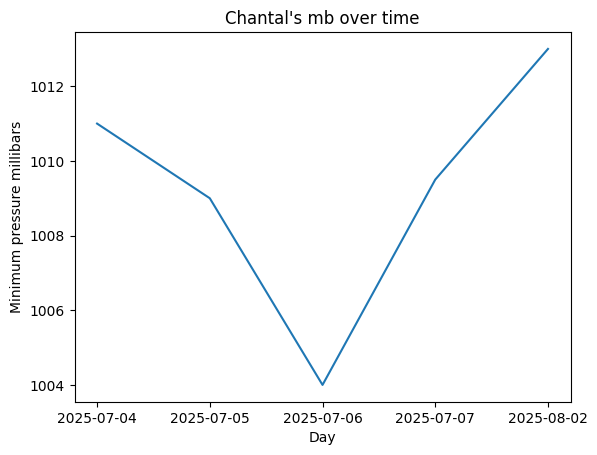

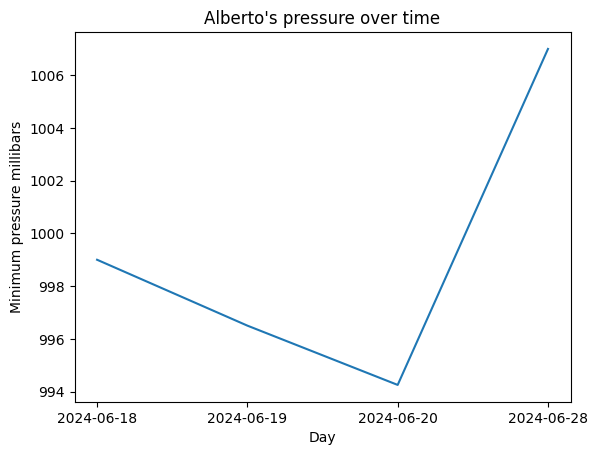

In [ ]:
#define shorter storms as under _ days
#shorter storms don't usually go under ___ mb
#lasted around 3 days, lowest point was 1000

#FIX THE DATES FOR THE LATER TWO

df_lorenzo = df_nodup[55546:55556]
df_l_date = df_lorenzo.groupby('date')['min_pressure_mb'].mean()
df_l_date = df_l_date.reset_index()

plt.plot(df_l_date['date'], df_l_date['min_pressure_mb'])

plt.title("Lorenzo's pressure over time")
plt.xlabel('Day')
plt.ylabel('Minimum pressure millibars')

plt.show()
################################################################################
#lasted around 5 days, lowest point was 1002
df_chantal = df_nodup[55255:55270]
df_c_date = df_chantal.groupby('date')['min_pressure_mb'].mean()
df_c_date = df_c_date.reset_index()

plt.plot(df_c_date['date'], df_c_date['min_pressure_mb'])

plt.title("Chantal's mb over time")
plt.xlabel('Day')
plt.ylabel('Minimum pressure millibars')

plt.show()
################################################################################
#lasted around 4 days, lowest point was 992
df_alberto = df_nodup[54749:54761]
df_a_date = df_alberto.groupby('date')['min_pressure_mb'].mean()
df_a_date = df_a_date.reset_index()

plt.plot(df_a_date['date'], df_a_date['min_pressure_mb'])

plt.title("Alberto's pressure over time")
plt.xlabel('Day')
plt.ylabel('Minimum pressure millibars')

plt.show()

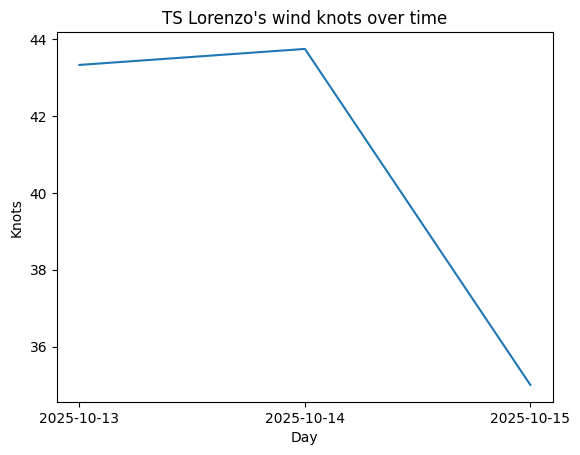

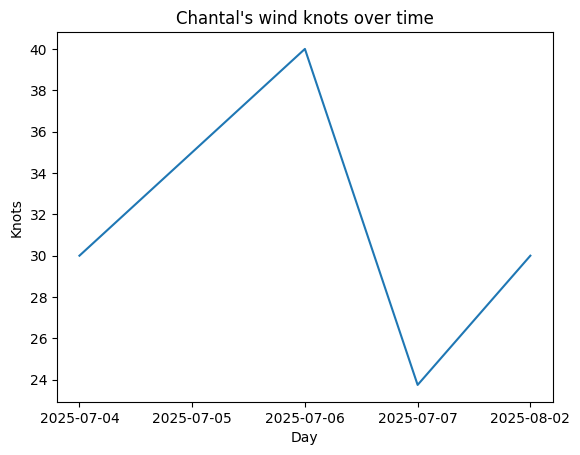

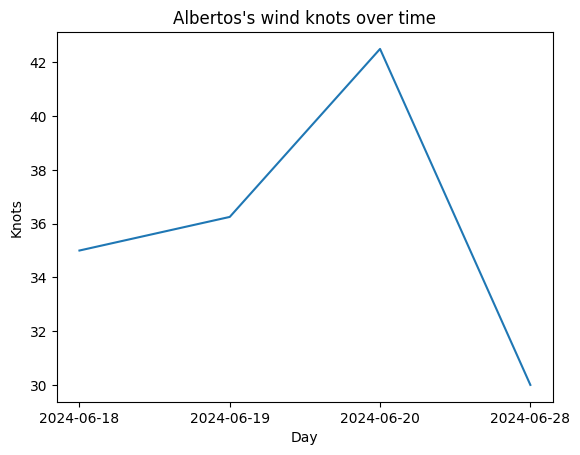

In [ ]:
#NOTE: this was a tropical storm(the entire time), meaning the wind speed is slower than a hurricane
#again, the lower the mb, the higher the knot
df_l_knot = df_lorenzo.groupby('date')['max_wind_knots'].mean()
df_l_knot = df_l_knot.reset_index()

plt.plot(df_l_knot['date'], df_l_knot['max_wind_knots'])

plt.title("TS Lorenzo's wind knots over time")
plt.xlabel('Day')
plt.ylabel('Knots')
plt.show()
################################################################################
df_c_knot = df_chantal.groupby('date')['max_wind_knots'].mean()
df_c_knot = df_c_knot.reset_index()

plt.plot(df_c_knot['date'], df_c_knot['max_wind_knots'])

plt.title("Chantal's wind knots over time")
plt.xlabel('Day')
plt.ylabel('Knots')
plt.show()
################################################################################
df_a_knot = df_alberto.groupby('date')['max_wind_knots'].mean()
df_a_knot = df_a_knot.reset_index()

plt.plot(df_a_knot['date'], df_a_knot['max_wind_knots'])

plt.title("Albertos's wind knots over time")
plt.xlabel('Day')
plt.ylabel('Knots')
plt.show()

____________________

In [ ]:
#notes for self :)
#as_index does the same thing as reset_index() - it turns the index into a columns of a df
#.agg 'combines' the multiple rows of each storm into one row by caculating the average and more
#the big chunk at the end just adds columns(min, max, and mean)
df_better = df_nodup.groupby(['storm_id', 'name'], as_index=False).agg(
    start_date=('date', 'min'),
    end_date=('date', 'max'),
    max_wind_knots=('max_wind_knots', 'max'),
    min_wind_knots=('max_wind_knots', 'min'),
    avg_wind_knots=('max_wind_knots', 'mean'),
    max_pressure_mb=('min_pressure_mb', 'max'),
    min_pressure_mb=('min_pressure_mb', 'min'),
    avg_pressure_mb=('min_pressure_mb', 'mean')

)

#converts the start and end date to datetime data type
df_better['start_date'] = pd.to_datetime(df_better['start_date'])
df_better['end_date'] = pd.to_datetime(df_better['end_date'])
df_better.dtypes

#computes duration of each hurricane by subtracting the start_date from the end_date.
df_better['duration_days'] = (df_better['end_date'] - df_better['start_date']).dt.days+1

df_better

,storm_id,name,start_date,end_date,max_wind_knots,min_wind_knots,avg_wind_knots,max_pressure_mb,min_pressure_mb,avg_pressure_mb,duration_days
0,AL011851,UNNAMED,1851-06-25,1851-06-28,80,40,60.714286,993.969541,962.969042,978.356284,4
1,AL011852,UNNAMED,1852-08-19,1852-08-30,100,40,73.333333,993.969541,943.493328,967.697744,12
2,AL011853,UNNAMED,1853-08-05,1853-08-05,50,50,50.000000,987.331263,987.331263,987.331263,1
3,AL011854,UNNAMED,1854-06-25,1854-06-27,70,40,58.181818,993.969541,971.776168,980.722421,3
4,AL011855,UNNAMED,1855-08-06,1855-08-06,90,90,90.000000,953.530595,953.530595,953.530595,1
...,...,...,...,...,...,...,...,...,...,...,...
1999,AL301969,UNNAMED,1969-08-07,1969-08-08,30,25,29.000000,1002.273382,999.744858,1000.250562,2
2000,AL302005,EPSILON,2005-11-29,2005-12-09,75,25,54.883721,1009.000000,981.000000,991.511628,11
2001,AL302020,THETA,2020-11-08,2020-11-16,60,25,42.121212,1014.000000,987.000000,998.939394,9
2002,AL312005,ZETA,2005-12-30,2006-01-07,55,25,42.361111,1016.000000,994.000000,1001.583333,9


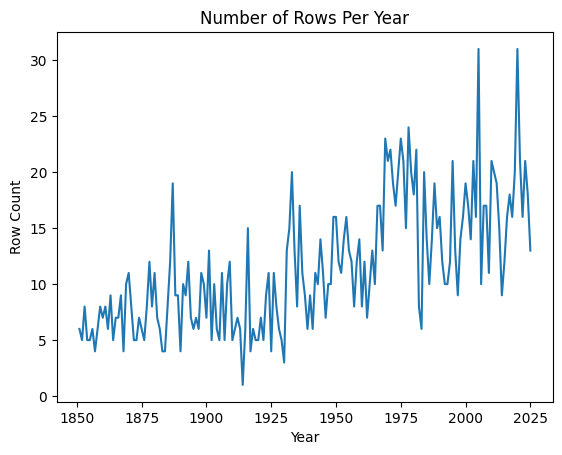

In [ ]:
df_better['year'] = df_better['start_date'].dt.year

yearly_counts = df_better['year'].value_counts().sort_index()

plt.plot(yearly_counts.index, yearly_counts.values)
plt.title('Number of Rows Per Year')
plt.xlabel('Year')
plt.ylabel('Row Count')
plt.show()

In [ ]:
#1960 bcs there is a change in the amount of hurricanes after that year(more)
df_1960=df_better[df_better['year']>=1960]
df_1960

,storm_id,name,start_date,end_date,max_wind_knots,min_wind_knots,avg_wind_knots,max_pressure_mb,min_pressure_mb,avg_pressure_mb,duration_days,year
109,AL011960,UNNAMED,1960-06-22,1960-06-28,50,20,28.888889,1013.000000,987.331263,1003.293369,7,1960
110,AL011961,ANNA,1961-07-17,1961-07-25,90,30,60.156250,1002.000000,958.326572,986.969368,9,1961
111,AL011962,ALMA,1962-08-26,1962-09-02,75,25,46.250000,1007.000000,967.453782,993.256306,8,1962
112,AL011963,ARLENE,1963-07-31,1963-08-14,100,25,46.545455,1012.000000,948.584988,991.690706,15,1963
113,AL011964,UNNAMED,1964-06-03,1964-06-11,60,25,38.382353,1007.000000,979.912952,995.739748,9,1964
...,...,...,...,...,...,...,...,...,...,...,...,...
1999,AL301969,UNNAMED,1969-08-07,1969-08-08,30,25,29.000000,1002.273382,999.744858,1000.250562,2,1969
2000,AL302005,EPSILON,2005-11-29,2005-12-09,75,25,54.883721,1009.000000,981.000000,991.511628,11,2005
2001,AL302020,THETA,2020-11-08,2020-11-16,60,25,42.121212,1014.000000,987.000000,998.939394,9,2020
2002,AL312005,ZETA,2005-12-30,2006-01-07,55,25,42.361111,1016.000000,994.000000,1001.583333,9,2005


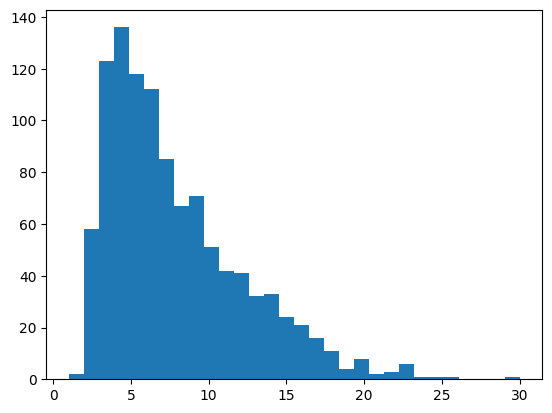

In [ ]:
plt.hist(df_1960['duration_days'], bins = 30)
plt.show()

In [ ]:
#if a hurricane lasts 7 or more days, consider it a 'long' hurricane. I tried other nearby values, there were no big differences.
#takes the average of the min/max/avg wind knots and the mb of two groups(7 days and longer or less than a weeek)

cutoff=7
df_1960['longer']=df_1960['duration_days']>=cutoff
df_plot=df_1960.groupby(['longer'],as_index=False).agg(
    avg_duration_days=('duration_days','mean'),
    avg_max_wind_knots = ('max_wind_knots','mean'),
    avg_min_wind_knots = ('min_wind_knots','mean'),
    avg_avg_wind_knots = ('avg_wind_knots','mean'),
    avg_max_pressure_mb=('max_pressure_mb','mean'),
    avg_min_pressure_mb =('min_pressure_mb','mean'),
    avg_avg_pressure_mb = ('avg_pressure_mb','mean')
)
df_plot

/tmp/ipykernel_1411/3861520018.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_1960['longer']=df_1960['duration_days']>=cutoff


,longer,avg_duration_days,avg_max_wind_knots,avg_min_wind_knots,avg_avg_wind_knots,avg_max_pressure_mb,avg_min_pressure_mb,avg_avg_pressure_mb
0,False,4.176685,44.972678,13.214936,33.182247,1007.759675,996.025465,1002.065607
1,True,11.257198,82.485605,23.798464,50.140985,1009.085189,968.646876,991.911715


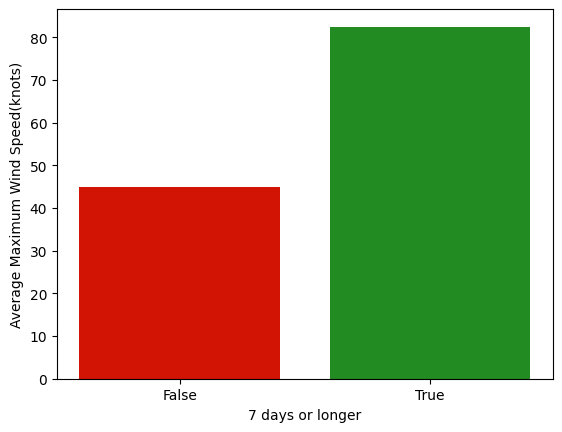

In [ ]:
df_plot[['longer','avg_avg_wind_knots']]

#longer is a boolean, so the x axis would be numbers(neg for false, pos for true), so you have to convert it into a str
plt.bar(df_plot['longer'].astype(str), df_plot['avg_max_wind_knots'], color = ['#D21404', '#228B22'])

plt.xlabel('7 days or longer')
plt.ylabel('Average Maximum Wind Speed(knots)')

plt.show()

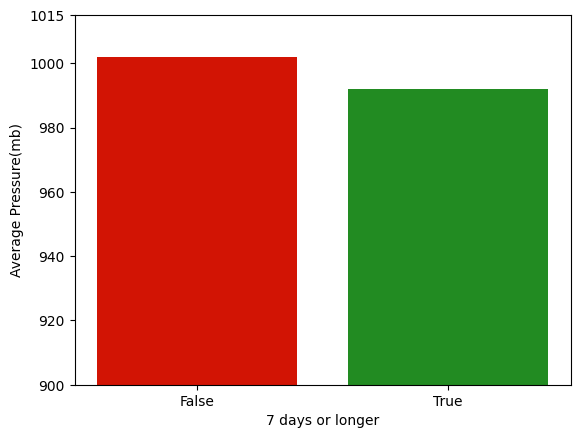

In [ ]:
df_plot[['longer','avg_avg_pressure_mb']]

plt.bar(df_plot['longer'].astype(str), df_plot['avg_avg_pressure_mb'], color = ['#D21404', '#228B22'])
plt.ylim(900, 1015)
plt.yticks([900, 920, 940, 960, 980, 1000, 1015])

plt.xlabel('7 days or longer')
plt.ylabel('Average Pressure(mb)')

plt.show()

In [ ]:
#Null Hypothesis: There is no significant difference in the mean of the windspeed of hurricanes
#lasting 7 days or longer and weather systems lasting less than 7 days in 1960.

long_lasting_wind = df_1960[df_1960['duration_days'] >= 7]['avg_wind_knots']
short_lasting_wind = df_1960[df_1960['duration_days'] < 7]['avg_wind_knots']

result = stats.ttest_ind(long_lasting_wind, short_lasting_wind)
p_value = result.pvalue
print(p_value)

#less than 0.05(don't forget about the e!), significant

4.793082239398862e-76


In [ ]:
#Null Hypothesis: There is no significant difference in the mean of the mb of hurricanes
#lasting 7 days or longer and weather systems lasting less than 7 days in 1960.

long_lasting_mb = df_1960[df_1960['duration_days'] >= 7]['min_pressure_mb']
short_lasting_mb = df_1960[df_1960['duration_days'] < 7]['min_pressure_mb']

result = stats.ttest_ind(long_lasting_mb, short_lasting_mb)
p_value = result.pvalue
print(p_value)

#less than 0.05, significant

1.6893071983367616e-89


In [ ]:
df_1960_features = df_1960[['avg_wind_knots', 'min_pressure_mb']]
label = df_1960['duration_days']

X_train, X_test, y_train, y_test = model_selection.train_test_split(
    df_1960_features, label, test_size=0.2, random_state=42
)

reg = LinearRegression()
reg.fit(X_train, y_train)

pred = reg.predict(X_test)

In [ ]:
r2 = metrics.r2_score(y_test, pred)
mae = metrics.mean_absolute_error(y_test, pred)
rmse = np.sqrt(metrics.mean_squared_error(y_test, pred))

print("R^2:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

#it can improve

R^2: 0.3676755065974666
MAE: 2.7891271119177423
RMSE: 3.957913755607256


To make the model more accurate, look at the starting latitude/longitude.

The water closer to the equator tends to be warmer, making it easier for a hurricane to appear. However, it also cannot be too close to the equator(Hurricanes cannot form within 5 degrees of the equator) because of the coriolis effect

Basically, the Coriolis Effect makes things traveling long distances around Earth appear to move at a curve as opposed to a straight line.
This is because if you are standing a foot to the right of the North or South Pole it would take 24 hours to move in a circle that is about six feet in circumference, about 0.00005 miles per hour.

But, if you were at the equator things are different. It still takes the Earth the same 24 hours to make a rotation, but this time we are traveling the circumference of the planet, about 25,000 miles long. This means you are traveling almost 1040 miles per hour just by standing there.

"Big storms like hurricanes and typhoons (tropical cyclones) are low-pressure systems. That means that they suck air into their center.

But as we just learned, air traveling long distances across Earth does not simply move in a straight line. Just like our soccer ball, the air being sucked into the storm deflects. This deflection is what causes tropical cyclones to spin."

In [ ]:
#get first row of each hurricane to see starting latitude and longitude.
#i'm adding the duration of each hurricane
df_nodup = df_nodup.sort_values(['storm_id','date','time'], ascending=True)
first_row = df_nodup.groupby('storm_id').first().reset_index()
first_row = first_row.merge(df_better[['storm_id','duration_days']], how='left', on=['storm_id'])

In [ ]:
#comparing latitude of longer/shorter hurricanes
long_lasting_lat = first_row[first_row['duration_days'] >= 7]['latitude']
short_lasting_lat = first_row[first_row['duration_days'] < 7]['latitude']

result = stats.ttest_ind(long_lasting_lat, short_lasting_lat)
p_value = result.pvalue
print(p_value)

#significant

1.833766611059295e-41


In [ ]:
#doing for longitude
long_lasting_long = first_row[first_row['duration_days'] >= 7]['longitude']
short_lasting_long = first_row[first_row['duration_days'] < 7]['longitude']

result = stats.ttest_ind(long_lasting_long, short_lasting_long)
p_value = result.pvalue
print(p_value)

1.7833159260137628e-36


In [ ]:
#merge df_1960 and first_row
df_combine = df_1960.merge(first_row[['storm_id','latitude','longitude']], how='left', on=['storm_id'])
df_combine

,storm_id,name,start_date,end_date,max_wind_knots,min_wind_knots,avg_wind_knots,max_pressure_mb,min_pressure_mb,avg_pressure_mb,duration_days,year,longer,latitude,longitude
0,AL011960,UNNAMED,1960-06-22,1960-06-28,50,20,28.888889,1013.000000,987.331263,1003.293369,7,1960,True,19.2,-93.2
1,AL011961,ANNA,1961-07-17,1961-07-25,90,30,60.156250,1002.000000,958.326572,986.969368,9,1961,True,10.5,-46.0
2,AL011962,ALMA,1962-08-26,1962-09-02,75,25,46.250000,1007.000000,967.453782,993.256306,8,1962,True,25.7,-79.7
3,AL011963,ARLENE,1963-07-31,1963-08-14,100,25,46.545455,1012.000000,948.584988,991.690706,15,1963,True,11.0,-39.4
4,AL011964,UNNAMED,1964-06-03,1964-06-11,60,25,38.382353,1007.000000,979.912952,995.739748,9,1964,True,18.5,-86.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1065,AL301969,UNNAMED,1969-08-07,1969-08-08,30,25,29.000000,1002.273382,999.744858,1000.250562,2,1969,False,22.0,-95.5
1066,AL302005,EPSILON,2005-11-29,2005-12-09,75,25,54.883721,1009.000000,981.000000,991.511628,11,2005,True,31.5,-49.2
1067,AL302020,THETA,2020-11-08,2020-11-16,60,25,42.121212,1014.000000,987.000000,998.939394,9,2020,True,28.4,-47.5
1068,AL312005,ZETA,2005-12-30,2006-01-07,55,25,42.361111,1016.000000,994.000000,1001.583333,9,2005,True,23.9,-35.6


In [ ]:
from sklearn.linear_model import LinearRegression

df_combine_features = df_combine[['avg_wind_knots','max_wind_knots' , 'min_wind_knots',
                                  'min_pressure_mb','max_pressure_mb', 'avg_pressure_mb',
                                  'longitude', 'latitude']]

label = df_combine['duration_days']

X_train, X_test, y_train, y_test = model_selection.train_test_split(
    df_combine_features, label, test_size=0.2, random_state=42
)

reg = LinearRegression()
reg.fit(X_train, y_train)

pred = reg.predict(X_test)

In [ ]:
r2 = metrics.r2_score(y_test, pred)
mae = metrics.mean_absolute_error(y_test, pred)
rmse = np.sqrt(metrics.mean_squared_error(y_test, pred))

print("R^2:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R^2: 0.4712908816725143
MAE: 2.425597492068321
RMSE: 3.619134508815415


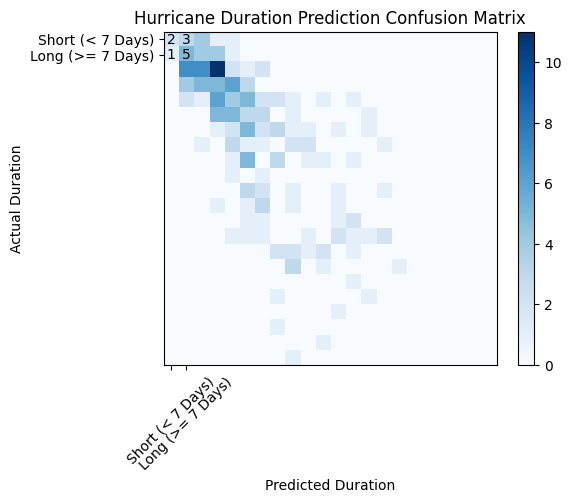

In [ ]:
from sklearn.metrics import confusion_matrix

# 1. Handle potential classification/Deep Learning formatting issues:
# Force values to clear binary format (0 = Short, 1 = Long)
y_test_fix = np.array(y_test).astype(int)
pred_fix = np.array(pred).astype(int)

# 2. Compute the raw matrix
cm = confusion_matrix(y_test_fix, pred_fix)

# 3. Explicitly define your two time-duration classes
classes = ["Short (< 7 Days)", "Long (>= 7 Days)"]

# 4. Generate the Heatmap Plot
plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")  # Uncommented and setup your color palette
plt.colorbar()                # Uncommented color scale tracking side bar

# Add descriptive plot titles and tick labels
plt.title("Hurricane Duration Prediction Confusion Matrix")
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

plt.xlabel("Predicted Duration")
plt.ylabel("Actual Duration")

# 5. Loop through matrix to annotate counts in cells (Fixed loops)
for i in range(len(classes)):
    for j in range(len(classes)):
        plt.text(
            j, i, format(cm[i, j], 'd'),
            ha="center",
            va="center",
            color="white" if cm[i, j] > cm.max() / 2. else "black"
        )

plt.tight_layout()
plt.show()


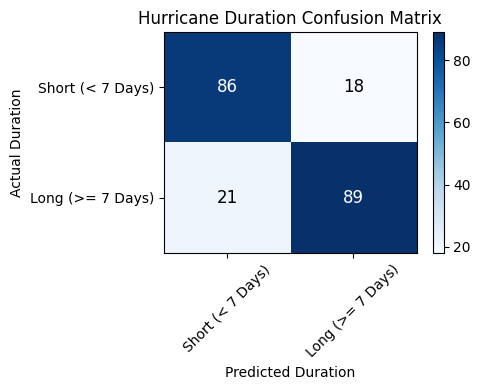

In [ ]:
from sklearn.metrics import confusion_matrix

THRESHOLD = 7

y_test_fix = (np.array(y_test) >= THRESHOLD).astype(int)
pred_fix = (np.array(pred) >= THRESHOLD).astype(int)

cm = confusion_matrix(y_test_fix, pred_fix)

# two categories
classes = ["Short (< 7 Days)", "Long (>= 7 Days)"]

#Heatmap
plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues", aspect="auto")
plt.colorbar()

# Add titles and adjust the ticks so they center correctly on a 2x2 grid
plt.title("Hurricane Duration Confusion Matrix")
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

plt.xlabel("Predicted Duration")
plt.ylabel("Actual Duration")

# 6. Annotate the 4 cells clearly
for i in range(2):
    for j in range(2):
        plt.text(
            j, i, format(cm[i, j], 'd'),
            ha="center",
            va="center",
            color="white" if cm[i, j] > cm.max() / 2. else "black",
            fontsize=12
        )

plt.tight_layout()
plt.show()


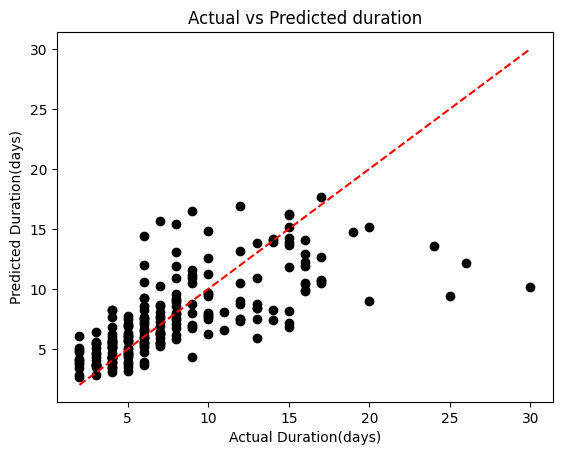

In [ ]:
plt.scatter(y_test, pred, color="black", label="Data")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--", label="Perfect Fit Line")

plt.title('Actual vs Predicted duration')
plt.xlabel('Actual Duration(days)')
plt.ylabel('Predicted Duration(days)')
plt.show()

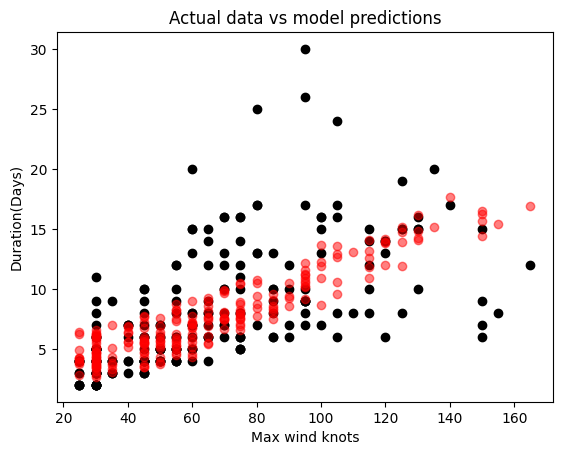

In [ ]:
plt.scatter(X_test['max_wind_knots'], y_test, color="black", label="Actual Data")
plt.scatter(X_test['max_wind_knots'], pred, color="red", alpha=0.5, label="Model Predictions")

plt.title('Actual data vs model predictions')
plt.xlabel('Max wind knots')
plt.ylabel('Duration(Days)')
plt.show()

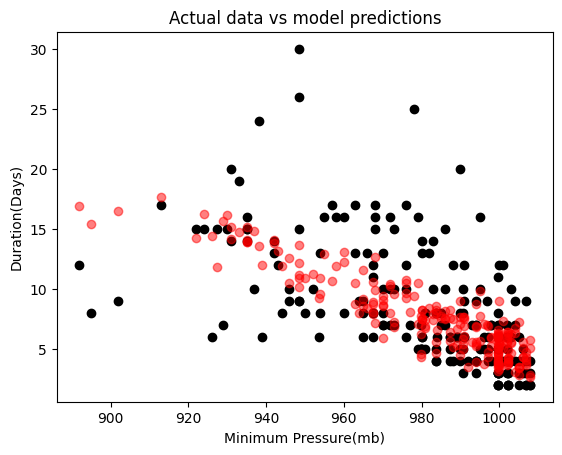

In [ ]:
plt.scatter(X_test['min_pressure_mb'], y_test, color="black", label="Actual Data")
plt.scatter(X_test['min_pressure_mb'], pred, color="red", alpha=0.5, label="Model Predictions")

plt.title('Actual data vs model predictions')
plt.xlabel('Minimum Pressure(mb)')
plt.ylabel('Duration(Days)')
plt.show()

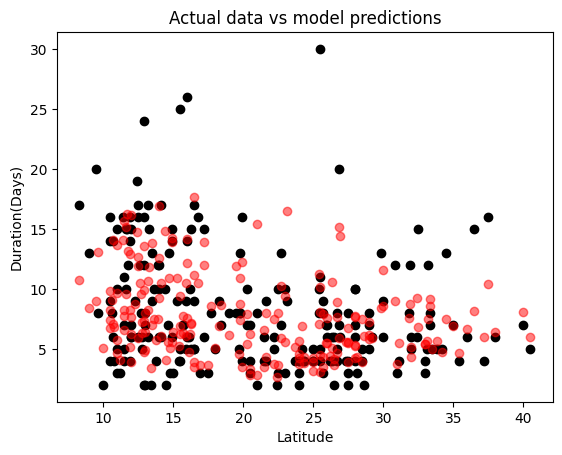

In [ ]:
plt.scatter(X_test['latitude'], y_test, color="black", label="Actual Data")
plt.scatter(X_test['latitude'], pred, color="red", alpha=0.5, label="Model Predictions")

plt.title('Actual data vs model predictions')
plt.xlabel('Latitude')
plt.ylabel('Duration(Days)')
plt.show()

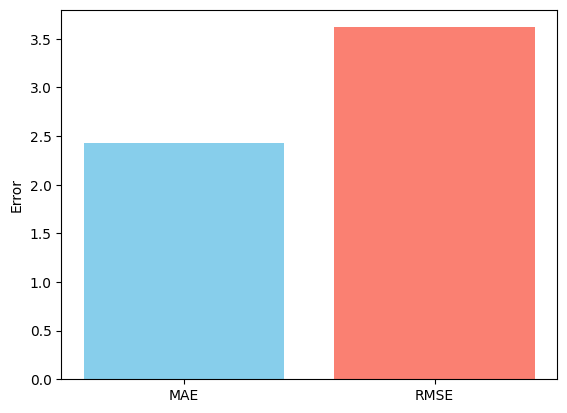

In [ ]:
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

# Create barplot
plt.bar(["MAE","RMSE"], [mae, rmse], color=["skyblue","salmon"])
plt.ylabel('Error')
plt.show()

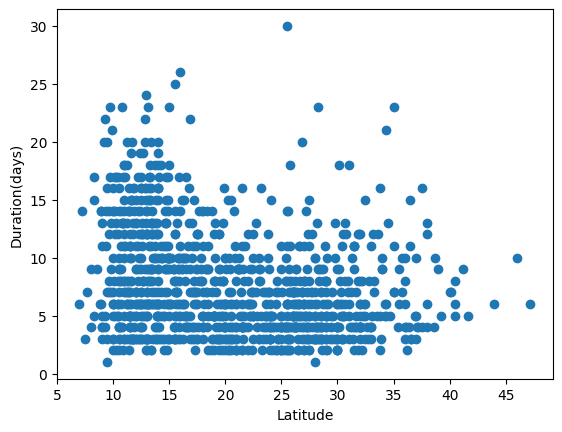

In [ ]:
plt.scatter(df_combine['latitude'], df_combine['duration_days'])

plt.xlabel('Latitude')
plt.ylabel('Duration(days)')

plt.show()

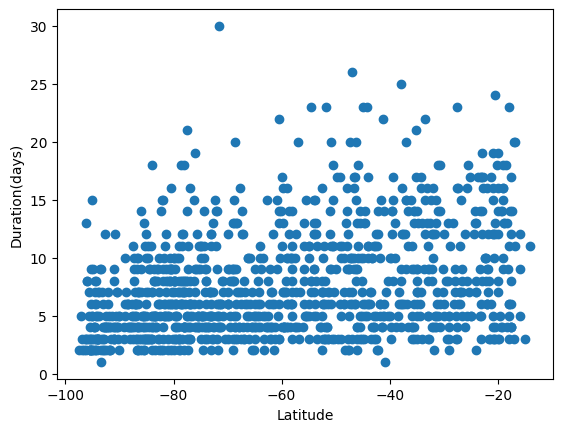

In [ ]:
plt.scatter(df_combine['longitude'], df_combine['duration_days'])

plt.xlabel('Latitude')
plt.ylabel('Duration(days)')

plt.show()